In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_curve,auc
from sklearn.linear_model import LogisticRegression

In [4]:
data=load_breast_cancer()
X=data.data
y=data.target
print("Dataset Shape:",X.shape)
print("Classes:",np.unique(y))

Dataset Shape: (569, 30)
Classes: [0 1]


In [4]:
data=load_breast_cancer()
X=data.data
y=data.target
print("Dataset Shape:",X.shape)
print("Classes:",np.unique(y))

Dataset Shape: (569, 30)
Classes: [0 1]


In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [11]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [16]:
mle_model=LogisticRegression(penalty=None,max_iter=5000,random_state=42)
mle_model.fit(X_train,y_train)
y_pred_mle=mle_model.predict(X_test)

In [21]:
map_l2=LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)
map_l2.fit(X_train,y_train)
y_pred_l2=map_l2.predict(X_test)

In [24]:
map_l1=LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=5000,
    random_state=42
)
map_l1.fit(X_train,y_train)
y_pred_l1=map_l1.predict(X_test)

In [33]:
def evaluate(model_name,y_true,y_pred):
    print("\n","="*40)
    print(model_name)
    print("="*40)
    print("Accuracy:",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall:",recall_score(y_true,y_pred))
    print("F1 Score:",f1_score(y_true,y_pred))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_true,y_pred))

In [42]:
evaluate("mle_model",y_test,y_pred_mle)
evaluate("MAP L1",y_test,y_pred_l1)
evaluate("MAP L2",y_test,y_pred_l2)


mle_model
Accuracy: 0.9210526315789473
Precision: 0.9701492537313433
Recall: 0.9027777777777778
F1 Score: 0.935251798561151

Confusion Matrix
[[40  2]
 [ 7 65]]

MAP L1
Accuracy: 0.9912280701754386
Precision: 0.9863013698630136
Recall: 1.0
F1 Score: 0.993103448275862

Confusion Matrix
[[41  1]
 [ 0 72]]

MAP L2
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]


In [44]:
print("Number of Zero Coefficients")
print("MLE   :",np.sum(mle_model.coef_[0]==0))
print("MAP L1:",np.sum(map_l2.coef_[0]==0))
print("MAP L2:",np.sum(map_l1.coef_[0]==0))

Number of Zero Coefficients
MLE   : 0
MAP L1: 0
MAP L2: 14


In [47]:
results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])
models=[
    ("MLE",mle_model,y_pred_mle),
    ("MAP L2",map_l2,y_pred_l2),
    ("MAP L1",map_l1,y_pred_l1)
]
for name,model,pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ]
print(results)

    Model  Accuracy  Precision    Recall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


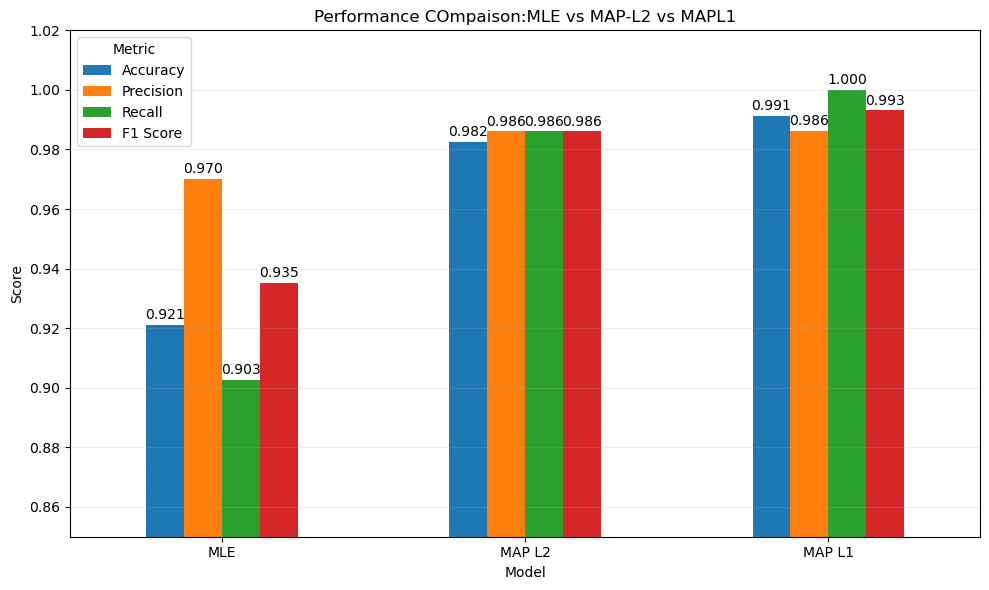

In [65]:
ax=results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Performance COmpaison:MLE vs MAP-L2 vs MAPL1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.2)
for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)
plt.tight_layout()
plt.show()

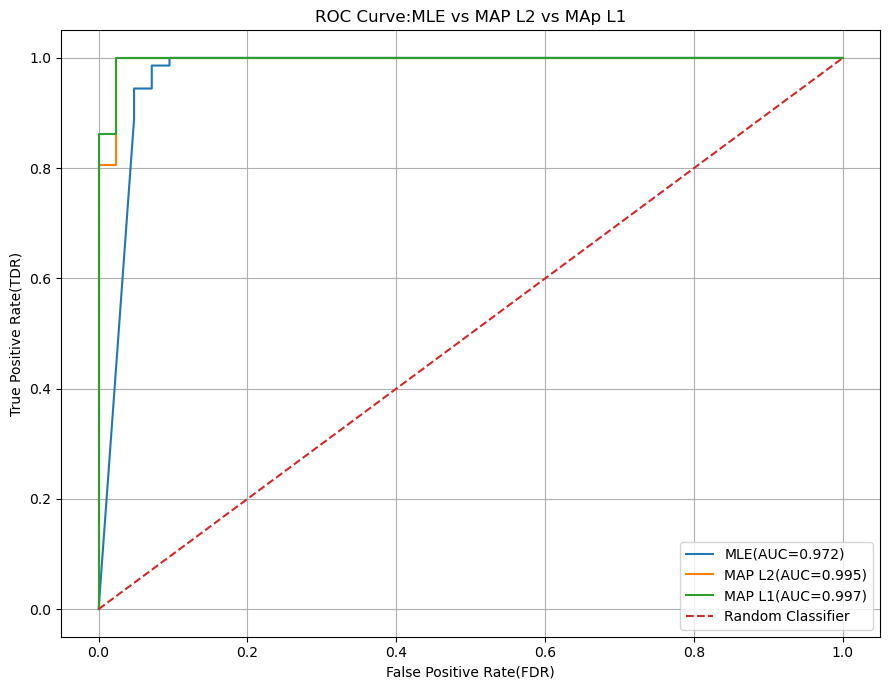

In [69]:
plt.figure(figsize=(9,7))
for name,model,pred in models:
    y_prob=model.predict_proba(X_test)[:,1]
    fpr,tpr,tresholds=roc_curve(y_test,y_prob)
    roc_auc=auc(fpr,tpr)
    plt.plot(
        fpr,
        tpr,label=f"{name}(AUC={roc_auc:.3f})"
    )
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate(FDR)")
plt.ylabel("True Positive Rate(TDR)")
plt.title("ROC Curve:MLE vs MAP L2 vs MAp L1")
plt.legend()
plt.grid(True)
plt.tight_layout()